# 기초통계 과제: DailyBox 마케팅 전략 분석

DailyBox 전략팀 분석가 입장에서, 지난 분기 쿠폰 캠페인 효과·채널별 고객 가치·매출 레버·타겟팅을 데이터로 검증합니다.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.outliers_influence import variance_inflation_factor

sns.set_style('whitegrid')
plt.rcParams['font.family'] = 'Noto Sans CJK JP'   # 한글 폰트 (Windows에서는 'Malgun Gothic'으로 바꿔서 실행하세요)
plt.rcParams['axes.unicode_minus'] = False

df = pd.read_csv('marketing_customers.csv')
df.head()

,customer_id,age,gender,signup_channel,membership_tier,monthly_visits,avg_discount_rate,online_ad_cost,offline_ad_cost,total_ad_cost,campaign_group,responded,monthly_spend
0,1,21,Female,Organic Search,Basic,10,0.140,16.56,0.34,16.90,control,0,35.10
1,2,47,Female,Referral,Silver,7,0.037,7.45,8.00,15.45,treatment,0,55.42
2,3,42,Female,Social Ads,Silver,8,0.347,20.54,6.92,27.46,treatment,1,86.58
3,4,27,Female,Referral,Silver,5,0.269,9.98,2.80,12.78,control,0,20.63
4,5,26,Female,Social Ads,Basic,13,0.157,6.83,0.57,7.40,treatment,1,25.43


## Part 1. 고객 이해 (EDA)

**1. 데이터 로드 및 구조 확인**

In [2]:
print(df.shape)
print(df.dtypes)
print(df.describe())
print(df.isna().sum())

(6000, 13)
customer_id            int64
age                    int64
gender                object
signup_channel        object
membership_tier       object
monthly_visits         int64
avg_discount_rate    float64
online_ad_cost       float64
offline_ad_cost      float64
total_ad_cost        float64
campaign_group        object
responded              int64
monthly_spend        float64
dtype: object
       customer_id          age  monthly_visits  avg_discount_rate  \
count  6000.000000  6000.000000     6000.000000        6000.000000   
mean   3000.500000    40.263333        8.201500           0.171374   
std    1732.195139    11.513402        4.221437           0.096024   
min       1.000000    18.000000        1.000000           0.000000   
25%    1500.750000    32.000000        5.000000           0.098000   
50%    3000.500000    40.000000        8.000000           0.158000   
75%    4500.250000    48.000000       11.000000           0.233250   
max    6000.000000    78.000000       

> ✍️ 고객 규모와 주요 수치 변수 범위 요약
>
> 총 6,000명의 고객 스냅샷이며 13개 변수 모두 결측치가 없습니다. 나이는 18~78세(평균 40.3세), 월 방문 횟수는 1~34회(평균 8.2회), 평균 할인율은 0~50%(평균 17.1%), 월 구매액(monthly_spend)은 8.26~288.44(평균 32.27, 중앙값 28.25)로 평균이 중앙값보다 커서 오른쪽 꼬리가 긴 분포임을 짐작할 수 있습니다.

**2. 매출 분포와 로그변환** — monthly_spend 왜도 계산 + log1p 전/후 비교

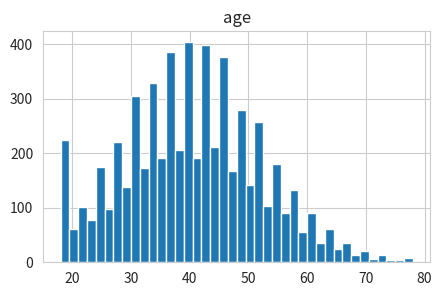

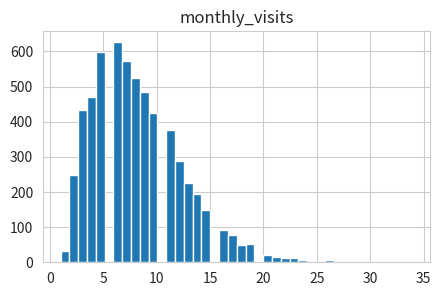

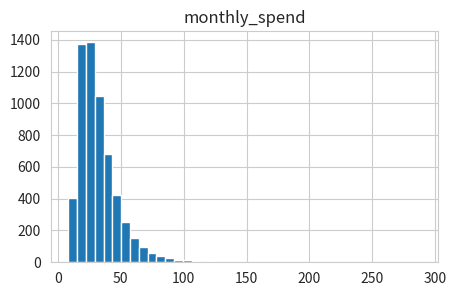

왜도 = 2.5456526289788064


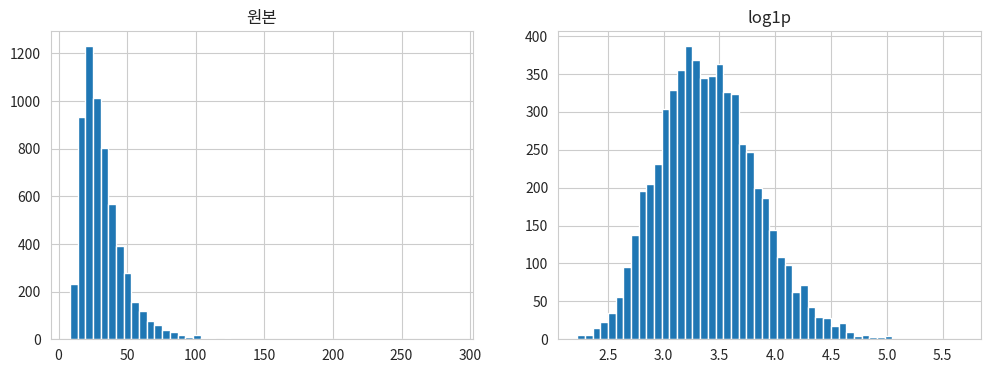

log1p 변환 후 왜도 = 0.3841605522825156


In [3]:
for col in ['age', 'monthly_visits', 'monthly_spend']:
    plt.figure(figsize=(5, 3))
    plt.hist(df[col], bins=40)
    plt.title(col); plt.show()

skew = df['monthly_spend'].skew()   # 왜도 메서드
print('왜도 =', skew)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['monthly_spend'], bins=50);            axes[0].set_title('원본')
axes[1].hist(np.log1p(df['monthly_spend']), bins=50)
axes[1].set_title('log1p'); plt.show()

print('log1p 변환 후 왜도 =', np.log1p(df['monthly_spend']).skew())

> ✍️ 매출 분포 해석
>
> monthly_spend의 왜도는 약 **2.55**로 강한 오른쪽 꼬리(right-skewed) 분포입니다. 대부분의 고객은 20~40 구간에 몰려 있지만, 일부 소수 고객이 100~288까지 매우 크게 지출하면서 평균을 끌어올리고 있습니다. 즉 "소수 고가치 고객에게 매출이 쏠려 있다"는 해석이 타당합니다.
>
> log1p 변환 후 왜도는 **0.38**로 크게 줄어들어 훨씬 대칭적인 분포가 됩니다. 회귀분석·t검정 등 여러 통계 기법은 (엄밀히는 잔차의) 정규성을 가정하는 경우가 많고, 큰 값 몇 개가 평균·분산 추정을 왜곡시키는 것을 로그변환이 완화해주기 때문에, 왜곡된 금액형 변수를 다룰 때 로그변환이 자주 쓰입니다.

**3. 채널·등급별 매출 Boxplot**

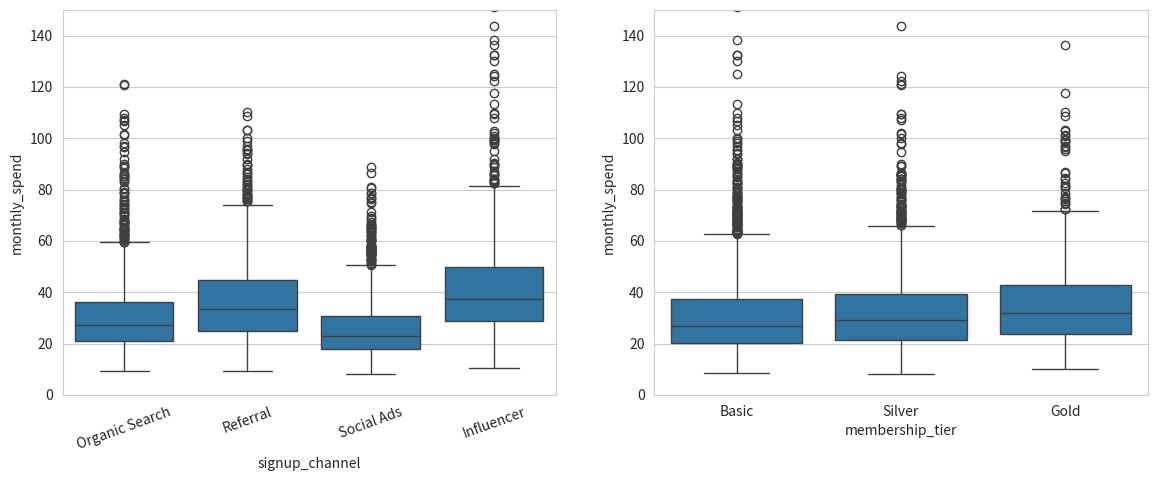

                     mean  median  count
signup_channel                          
Influencer      42.869433  37.530    917
Referral        36.689813  33.310   1230
Organic Search  30.511203  27.120   2061
Social Ads      25.851708  23.055   1792
                      mean  median  count
membership_tier                          
Basic            30.897325   26.70   3215
Gold             36.480685   31.97    774
Silver           32.858598   29.34   2011


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df, x='signup_channel', y='monthly_spend', ax=axes[0])
axes[0].set_ylim(0, 150); axes[0].tick_params(axis='x', rotation=20)
sns.boxplot(data=df, x='membership_tier', y='monthly_spend',
            order=['Basic', 'Silver', 'Gold'], ax=axes[1])
axes[1].set_ylim(0, 150); plt.show()

print(df.groupby('signup_channel')['monthly_spend'].agg(['mean','median','count']).sort_values('mean', ascending=False))
print(df.groupby('membership_tier')['monthly_spend'].agg(['mean','median','count']))

> ✍️ 채널/등급별 해석
>
> 채널별 평균 monthly_spend는 **Influencer(42.9) > Referral(36.7) > Organic Search(30.5) > Social Ads(25.9)** 순입니다. Influencer와 Referral 채널이 눈에 띄게 고가치 고객을 데려오는 반면, Social Ads는 표본 수(1,792명)가 가장 많은 채널 중 하나임에도 평균 매출이 가장 낮습니다.
>
> 멤버십 등급은 Gold(36.5) > Silver(32.9) > Basic(30.9) 순으로, 등급 체계가 실제 구매액과 잘 정렬되어 있습니다(등급이 매출에 따라 부여되는 구조라면 당연한 결과이기도 합니다).

## Part 2. 가정 확인

**4. 1종/2종 오류 (개념)**

> ✍️ H0: "쿠폰 캠페인은 매출에 효과가 없다"
>
> - **1종 오류 (실제로는 효과가 없는데, 있다고 잘못 판단)**: 회사는 효과 없는 캠페인을 계속 운영하며 쿠폰 비용·마케팅 예산을 낭비하게 됩니다. 매 분기 불필요한 할인 원가가 새어나가는 셈입니다.
> - **2종 오류 (실제로는 효과가 있는데, 없다고 잘못 판단)**: 실제로 매출을 끌어올리는 캠페인을 "효과 없다"고 오판해 중단하면, 얻을 수 있었던 추가 매출(기회)을 놓치게 됩니다. 이는 예산 낭비보다 눈에 덜 띄지만 명백한 기회비용 손실입니다.
>
> 즉 1종 오류는 "쓰지 않아도 될 돈을 쓰는 것", 2종 오류는 "벌 수 있었던 돈을 못 버는 것"에 해당합니다.

**5. 정규성 검정 (Shapiro-Wilk) — 원본 vs 로그**

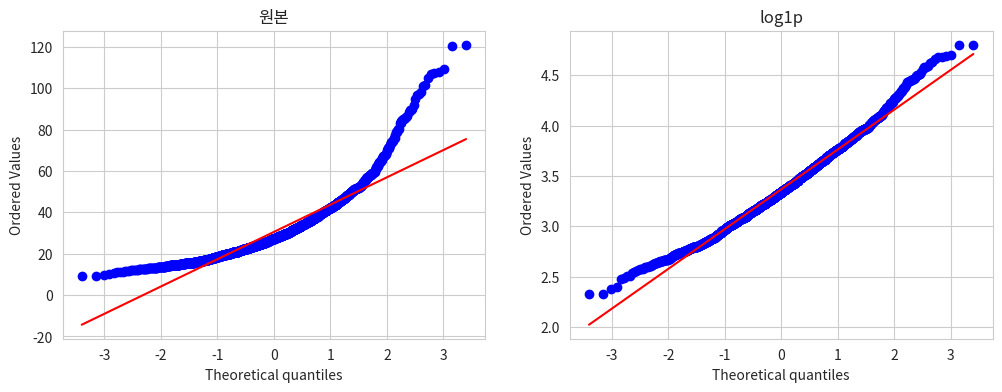

원본   ShapiroResult(statistic=np.float64(0.8534533976380867), pvalue=np.float64(3.631642400263992e-21))
log1p  ShapiroResult(statistic=np.float64(0.9873230180962405), pvalue=np.float64(0.0002448611612826312))


In [5]:
x = df.loc[df.signup_channel == 'Organic Search', 'monthly_spend']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
stats.probplot(x, dist='norm', plot=axes[0]);            axes[0].set_title('원본')
stats.probplot(np.log1p(x), dist='norm', plot=axes[1]);  axes[1].set_title('log1p')
plt.show()

xs = x.sample(500, random_state=0)
print('원본  ', stats.shapiro(xs))
print('log1p ', stats.shapiro(np.log1p(xs)))

> ✍️ 가설: H0 = "이 표본은 정규분포를 따른다" / H1 = "정규분포를 따르지 않는다"
>
> 원본 monthly_spend는 Shapiro-Wilk p-value가 0.05보다 훨씬 작아(사실상 0에 가까움) H0를 기각합니다 — 정규분포를 따르지 않습니다(Q-Q plot에서도 오른쪽 꼬리가 직선에서 크게 벗어남). log1p 변환 후에도 표본 크기가 크기 때문에 형식적으로는 p<0.05로 여전히 H0가 기각되지만, 검정통계량(W)이 원본보다 1에 훨씬 가까워지고 Q-Q plot도 직선에 훨씬 가깝게 개선됩니다. 즉 "완벽한 정규분포"는 아니어도 실질적으로 훨씬 정규분포에 가까워졌다고 해석할 수 있습니다. (문제 지시대로 이후 분석은 정규성을 만족한다고 가정하고 진행합니다.)

**6. 등분산성 검정**

In [6]:
groups = [g['monthly_spend'].values for _, g in df.groupby('signup_channel')]
stat, p = stats.levene(*groups)
print('Levene stat =', stat, ' p =', p)

Levene stat = 69.36163979257071  p = 4.335927248200273e-44


> ✍️ Levene 검정 결과 p-value가 0.05보다 훨씬 작아(귀무가설 "모든 채널의 분산이 같다"를 기각) **4개 채널 간 monthly_spend의 분산이 서로 다릅니다(등분산 가정 위반)**. One-way ANOVA는 등분산을 가정하는 검정이라 이 결과는 이후 8번 ANOVA 해석에 주의가 필요하다는 뜻입니다. 다만 ANOVA는 표본 크기가 크고 그룹별 표본 수 차이가 극단적이지 않으면 어느 정도 강건(robust)하다고 알려져 있어, 참고 정보로 해석 시 유의하며 진행합니다.

## Part 3. 집단 비교 검정

**7. 쿠폰 캠페인 효과 검증 — 두 집단 평균 비교 (Welch's t-test)**

In [7]:
ctrl = df.loc[df.campaign_group == 'control', 'monthly_spend']
trt  = df.loc[df.campaign_group == 'treatment', 'monthly_spend']
print('평균', ctrl.mean(), trt.mean())

print('Levene p =', stats.levene(ctrl, trt).pvalue)
# 등분산이 깨지면 equal_var=False (Welch)
t, p = stats.ttest_ind(ctrl, trt, equal_var=False)
print('t=%.2f p=%.3g' % (t, p))

평균 29.707517635203224 34.80327820046312
Levene p = 1.164492092129461e-19
t=-11.88 p=3.86e-32


> ✍️ H0: "treatment(쿠폰 발송)와 control(미발송) 그룹의 monthly_spend 평균은 같다" / H1: "두 그룹의 평균은 다르다"
>
> Levene 검정 p-value가 0.05보다 작아 등분산 가정이 깨지므로 Welch's t-test를 사용했습니다. 결과 t≈-11.88, p≈3.9e-32로 0.05보다 압도적으로 작아 **H0를 기각**합니다. control 평균은 29.71, treatment 평균은 34.80으로 쿠폰을 받은 고객이 약 5.10(상대적으로 약 17%) 더 많이 지출했습니다. campaign_group이 무작위 배정이었으므로 이 차이는 캠페인의 인과적 효과로 해석할 수 있습니다. **결론: 다음 분기에도 캠페인을 지속하는 것이 타당합니다.**

**8. 채널 비교 — One-way ANOVA + Tukey HSD**

In [8]:
F, p = stats.f_oneway(*groups)
print('ANOVA F=%.2f p=%.3g' % (F, p))

tukey = pairwise_tukeyhsd(df['monthly_spend'], df['signup_channel'], alpha=0.05)
print(tukey)

ANOVA F=276.85 p=2.67e-168


         Multiple Comparison of Means - Tukey HSD, FWER=0.05         
    group1         group2     meandiff p-adj  lower    upper   reject
---------------------------------------------------------------------
    Influencer Organic Search -12.3582   0.0 -13.9696 -10.7469   True
    Influencer       Referral  -6.1796   0.0  -7.9507  -4.4086   True
    Influencer     Social Ads -17.0177   0.0 -18.6659 -15.3696   True
Organic Search       Referral   6.1786   0.0    4.716   7.6412   True
Organic Search     Social Ads  -4.6595   0.0  -5.9706  -3.3484   True
      Referral     Social Ads -10.8381   0.0 -12.3412   -9.335   True
---------------------------------------------------------------------


> ✍️ H0: "4개 채널의 monthly_spend 평균은 모두 같다" / H1: "적어도 한 채널의 평균은 다르다"
>
> ANOVA 결과 F≈276.85, p≈2.7e-168로 H0를 강하게 기각합니다 — 채널 간 매출 평균에 유의한 차이가 있습니다. Tukey HSD 사후검정 결과 **6개 채널 쌍 전부(reject=True)** 유의하게 다릅니다. 평균이 높은 순으로 Influencer(42.9) > Referral(36.7) > Organic Search(30.5) > Social Ads(25.9)이며, 가장 큰 차이는 Influencer-Social Ads(약 17.0)입니다. Boxplot과 종합하면 **Influencer와 Referral 채널이 통계적으로 유의하게 고가치 고객을 데려오고, Social Ads는 저가치 고객 비중이 높습니다.**

**9. 교호작용 — Two-way ANOVA (선택 심화)**

In [9]:
model = smf.ols('monthly_spend ~ C(signup_channel) * C(campaign_group)', data=df).fit()
print(sm.stats.anova_lm(model, typ=2))

                                           sum_sq      df           F  \
C(signup_channel)                    2.069851e+05     3.0  284.971525   
C(campaign_group)                    3.868639e+04     1.0  159.787112   
C(signup_channel):C(campaign_group)  6.749231e+03     3.0    9.292159   
Residual                             1.450735e+06  5992.0         NaN   

                                            PR(>F)  
C(signup_channel)                    6.336934e-173  
C(campaign_group)                     3.634363e-36  
C(signup_channel):C(campaign_group)   3.973329e-06  
Residual                                       NaN  


> ✍️ 채널 주효과(p≈6.3e-173), 캠페인 주효과(p≈3.6e-36) 모두 매우 유의하고, **채널×캠페인 교호작용도 유의**합니다(p≈4.0e-6, <0.05). 이는 "캠페인 효과가 모든 채널에서 동일한 크기로 나타나지 않는다"는 뜻입니다. 즉 쿠폰 캠페인의 매출 증대 효과가 채널에 따라 더 크거나 작을 수 있으므로, 다음 캠페인 예산을 짤 때 채널별로 캠페인 반응도를 감안한 차등 전략이 필요합니다.

## Part 4. 회귀분석

**10. 단순선형회귀 & 다중회귀**

In [10]:
# 단순
m1 = smf.ols('monthly_spend ~ monthly_visits', data=df).fit()
print(m1.summary().tables[1]); print('R2 =', m1.rsquared)

                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         24.6737      0.462     53.357      0.000      23.767      25.580
monthly_visits     0.9268      0.050     18.487      0.000       0.829       1.025
R2 = 0.05390927563052861


In [11]:
# 다중 (범주형은 C()로 더미코딩)
m2 = smf.ols(
    'monthly_spend ~ monthly_visits + avg_discount_rate + online_ad_cost '
    '+ C(signup_channel) + C(gender)', data=df).fit()
print(m2.summary())
print('단순 adjR2=%.4f / 다중 adjR2=%.4f' % (m1.rsquared_adj, m2.rsquared_adj))

                            OLS Regression Results                            
Dep. Variable:          monthly_spend   R-squared:                       0.218
Model:                            OLS   Adj. R-squared:                  0.217
Method:                 Least Squares   F-statistic:                     238.3
Date:                Mon, 20 Jul 2026   Prob (F-statistic):          9.35e-314
Time:                        20:20:05   Log-Likelihood:                -24723.
No. Observations:                6000   AIC:                         4.946e+04
Df Residuals:                    5992   BIC:                         4.952e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                          coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
In

> ✍️ 단순회귀에서 monthly_visits 계수는 0.927(R²=0.054) — 방문 1회당 매출이 약 0.93 증가하지만 방문 횟수만으로는 매출 변동의 5.4%밖에 설명하지 못합니다.
>
> 다중회귀(R²=0.218, adjR²=0.217)는 단순회귀보다 설명력이 4배 가까이 높습니다. 계수 해석:
> - monthly_visits: +0.917 (다른 변수 고정 시 방문 1회당 매출 +0.92, 단순회귀와 비슷한 크기로 안정적인 레버)
> - avg_discount_rate: +11.42 (할인율이 높을수록 매출도 높음 — 다만 이는 상관관계이며, 할인이 매출을 유발했는지 / 원래 많이 쓰는 고객에게 할인을 더 많이 줬는지는 이 데이터만으로 인과 판단이 어렵습니다. "할인 확대 = 매출 증가"로 단순 해석하는 것은 위험합니다)
> - online_ad_cost: +0.368 (고객 획득 광고비가 클수록 매출도 큰 경향 — 광고비를 많이 쓴 고객일수록 고가치일 수 있다는 상관관계이지, 광고비를 더 쓰면 매출이 는다는 인과관계로 바로 해석하긴 어렵습니다)
> - signup_channel 더미(기준=Influencer): Organic Search -12.19, Referral -5.86, Social Ads -16.70 — 다른 조건이 같아도 Influencer 대비 매출이 낮음 (8번 결과와 일치)
> - gender[Male]: -2.73 (남성이 여성보다 평균적으로 매출이 낮음)
>
> 종합하면 **monthly_visits(방문 빈도)가 가장 해석하기 안전한 매출 레버**이고, 할인율·광고비는 상관관계는 강하지만 인과관계로 단정하기엔 추가 실험(A/B 테스트 등)이 필요합니다.

**11. 다중공선성 / VIF** — online + offline + total 모두 넣기

In [12]:
def vif_table(X):
    X = sm.add_constant(X)
    return pd.DataFrame({'feature': X.columns,
        'VIF': [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]})

X_bad = df[['monthly_visits', 'online_ad_cost', 'offline_ad_cost', 'total_ad_cost']]
print(vif_table(X_bad))

X_ok = df[['monthly_visits', 'online_ad_cost', 'offline_ad_cost']]  # total 제거
print(vif_table(X_ok))

           feature       VIF
0            const  8.212525
1   monthly_visits  1.000060
2   online_ad_cost       inf
3  offline_ad_cost       inf
4    total_ad_cost       inf
           feature       VIF
0            const  8.212525
1   monthly_visits  1.000060
2   online_ad_cost  1.000251
3  offline_ad_cost  1.000213


/sessions/great-admiring-einstein/.local/lib/python3.10/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


> ✍️ online_ad_cost, offline_ad_cost, total_ad_cost를 모두 넣으면 세 변수의 VIF가 **무한대(inf)**로 튑니다. 이는 total_ad_cost가 정의상 online_ad_cost + offline_ad_cost로 완전히 결정되는 값이라, 세 변수 사이에 완벽한 선형 종속관계(완전 다중공선성)가 존재하기 때문입니다 — 회귀식이 세 계수를 유일하게 추정할 수 없는 상태가 됩니다.
>
> total_ad_cost를 제거하면 online_ad_cost, offline_ad_cost의 VIF가 모두 1.0 근처로 떨어져 다중공선성 문제가 완전히 사라집니다. **해결책은 셋 중 하나(보통 정의상 계산된 total_ad_cost)를 회귀식에서 제외**하는 것이며, 만약 총 광고비 자체를 보고 싶다면 online/offline을 빼고 total_ad_cost 하나만 넣는 식으로 목적에 맞게 변수를 선택해야 합니다.

**12. 잔차 진단** (+ 로그변환 비교)

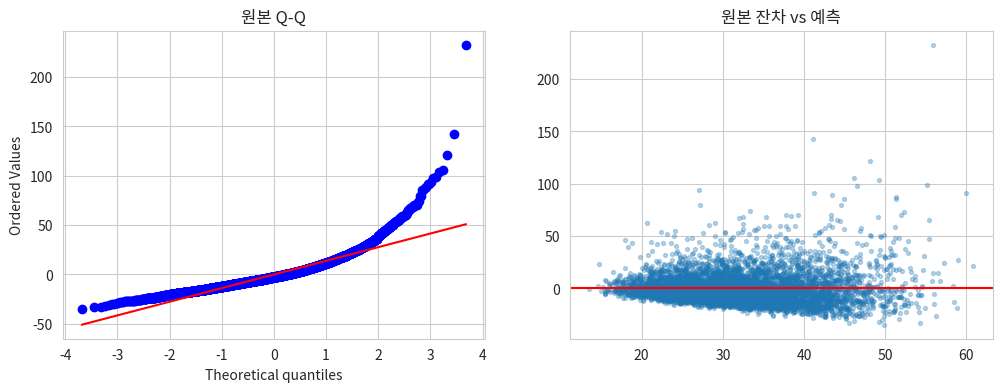

원본 Shapiro: ShapiroResult(statistic=np.float64(0.8653584771760595), pvalue=np.float64(2.3966538861720755e-54))


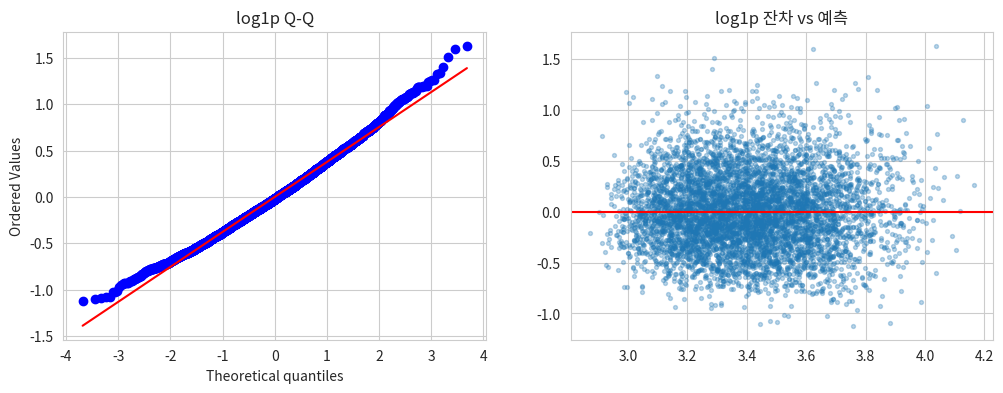

log1p Shapiro: ShapiroResult(statistic=np.float64(0.9949624704280046), pvalue=np.float64(3.492270122981846e-12))
원본 모형 R2=0.2178 / log1p 모형 R2=0.2479


In [13]:
def resid_plots(model, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    stats.probplot(model.resid, dist='norm', plot=axes[0]); axes[0].set_title(title+' Q-Q')
    axes[1].scatter(model.fittedvalues, model.resid, s=8, alpha=0.3)
    axes[1].axhline(0, color='red'); axes[1].set_title(title+' 잔차 vs 예측')
    plt.show()
    print(title, 'Shapiro:', stats.shapiro(model.resid.sample(min(len(model.resid), 5000), random_state=1)))

resid_plots(m2, '원본')

m2_log = smf.ols('np.log1p(monthly_spend) ~ monthly_visits + avg_discount_rate '
                 '+ online_ad_cost + C(signup_channel) + C(gender)', data=df).fit()
resid_plots(m2_log, 'log1p')

print('원본 모형 R2=%.4f / log1p 모형 R2=%.4f' % (m2.rsquared, m2_log.rsquared))

> ✍️ 원본 모형(m2)의 잔차는 Q-Q plot에서 오른쪽 꼬리가 직선을 크게 벗어나고, 잔차 vs 예측값 산점도에서도 예측값이 커질수록 잔차가 위로 퍼지는 깔때기 모양이 나타나 정규성·등분산성 가정이 모두 깨져 보입니다(Shapiro-Wilk 통계량도 약 0.865로 1에서 꽤 떨어져 있음).
>
> 종속변수를 log1p(monthly_spend)로 바꾼 모형(m2_log)은 Q-Q plot이 직선에 훨씬 가까워지고, 잔차 산점도도 0을 중심으로 더 고르게 흩어지며, Shapiro 통계량도 약 0.995로 1에 매우 가까워집니다. R²도 0.218→0.248로 개선됩니다. **로그변환 모형이 회귀 가정을 훨씬 더 잘 만족하므로, 실제 해석·보고에는 로그변환 모형을 우선 사용하는 것이 바람직합니다** (단, 계수 해석 시 로그 스케일이라는 점에 유의).

## Part 5. 타겟팅 (로지스틱 회귀)

**13~14. 로지스틱 회귀 & 오즈비 해석**

In [14]:
logit = smf.logit(
    'responded ~ age + monthly_visits + C(campaign_group) + C(membership_tier) '
    '+ C(signup_channel)', data=df).fit()
print(logit.summary())

odds = pd.DataFrame({'coef': logit.params, 'p': logit.pvalues,
                     'odds_ratio': np.exp(logit.params)})
print(odds.round(3))

Optimization terminated successfully.
         Current function value: 0.512887
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:              responded   No. Observations:                 6000
Model:                          Logit   Df Residuals:                     5991
Method:                           MLE   Df Model:                            8
Date:                Mon, 20 Jul 2026   Pseudo R-squ.:                 0.06405
Time:                        20:20:05   Log-Likelihood:                -3077.3
converged:                       True   LL-Null:                       -3287.9
Covariance Type:            nonrobust   LLR p-value:                 5.453e-86
                                          coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
Intercept                              -2.2301      0.157 

> ✍️ 모든 변수가 p<0.001로 유의합니다. 오즈비로 해석하면:
>
> - **campaign_group[treatment]: OR=2.43** — 쿠폰을 받은 고객은 안 받은 고객보다 반응(전환) 오즈가 2.43배 높습니다. (실제 반응률도 control 16.1% vs treatment 31.2%로 거의 2배 차이)
> - **membership_tier**: Gold OR=2.02, Silver OR=1.41 (Basic 대비) — 등급이 높을수록 캠페인에 더 잘 반응합니다.
> - signup_channel: Organic Search·Referral·Social Ads 모두 OR<1(0.52~0.59, Influencer 대비) — Influencer 채널 고객이 가장 반응률이 높습니다.
> - age(OR=1.013), monthly_visits(OR=1.041) — 나이와 방문 빈도가 높을수록 반응 오즈가 소폭 증가합니다.
>
> **결론: 다음 캠페인은 (1) Gold/Silver 등급, (2) Influencer 채널로 유입된, (3) 방문 빈도가 높은 고객군에 쿠폰을 집중 발송할 때 반응률이 가장 높을 것으로 예상됩니다.**

## 종합 결론 — CMO 보고용 마케팅 전략

> ✍️ (요약본입니다. 상세 전략 제안은 `report.pdf`에 정리했습니다.)
>
> 1. **캠페인 지속 여부**: 지속 권장. Welch's t-test(7번)에서 쿠폰 발송군의 매출이 유의하게 높고(+17%), 로지스틱 회귀(14번)에서도 발송군의 반응 오즈가 2.43배로 뚜렷한 효과가 확인됩니다.
> 2. **채널 예산 배분**: Influencer·Referral 채널에 예산 비중 확대, Social Ads는 축소 검토(3·8번 근거 — 평균 매출·Tukey 사후검정 기준 두 채널 그룹이 통계적으로 유의하게 구분됨).
> 3. **매출 레버**: monthly_visits(방문 빈도)가 가장 안정적으로 해석 가능한 레버(10번). 할인율·광고비는 매출과 상관은 있으나 인과관계 증거가 약해 무분별한 할인 확대는 권장하지 않음.
> 4. **타겟팅**: Gold/Silver 등급 + Influencer 채널 + 고빈도 방문 고객에게 다음 캠페인 집중(14번 근거).
> 5. **분석의 한계**: 한 달 스냅샷이라 계절성·장기 추세 반영 불가, online/offline/total_ad_cost처럼 정의상 종속된 변수 존재(다중공선성 주의), 회귀분석의 할인율·광고비 계수는 상관관계이지 인과관계로 단정할 수 없음(실험적 설계가 아닌 관찰 데이터 기반).